---
## 0. Setup & Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1f2e',
    'axes.edgecolor':   '#2d3561',
    'axes.labelcolor':  '#cdd6f4',
    'xtick.color':      '#8892b0',
    'ytick.color':      '#8892b0',
    'text.color':       '#cdd6f4',
    'grid.color':       '#2d3561',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'axes.titlepad':    12,
    'figure.titlesize': 16,
})

PALETTE = ['#80d8ff','#50fa7b','#f1fa8c','#ffb86c','#ff79c6','#bd93f9','#8be9fd','#ff5555']
sns.set_palette(PALETTE)

print(" Libraries loaded successfully")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   seaborn {sns.__version__}")

 Libraries loaded successfully
   pandas  3.0.1
   numpy   2.4.3
   seaborn 0.13.2


---
## 1. Load Data & Exploratory Data Analysis (EDA)


In [2]:
import pandas as pd

# loading the dataset
# Đã thêm .xlsx vào cuối đường dẫn
FILE = r'C:\CRM and Sales Pipelines\notebook\CRM and Sales Pipelines.xlsx'
df = pd.read_excel(FILE)

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")
df.head() 

Shape: 3,000 rows × 17 columns

Columns: ['Organization', 'Country', 'Lattitude', 'Longitude', 'Industry', 'Organization size', 'Owner', 'Lead acquisition date', 'Product', 'Status', 'Status sequence', 'Stage', 'Stage sequence', 'Deal Value, $', 'Probability, %', 'Expected close date', 'Actual close date']


,Organization,Country,Lattitude,Longitude,Industry,Organization size,Owner,Lead acquisition date,Product,Status,Status sequence,Stage,Stage sequence,"Deal Value, $","Probability, %",Expected close date,Actual close date
0,Thoughtblab,Netherlands,52.370216,4.895168,Banking and Finance,Small (11-200),John Smith,2024-04-20,SAAS,Churned Customer,7,NaN,NaN,833,90,2024-08-07,2024-06-27
1,Jaxnation,Spain,40.416775,-3.703790,Energy & Utilities,Small (11-200),Emily Johnson,2024-05-28,SAAS,Churned Customer,7,NaN,NaN,1623,30,2024-10-25,2024-09-11
2,Mybuzz,Italy,41.902782,12.496366,Education & Science,Small (11-200),Michael Brown,2024-03-17,SAAS,Churned Customer,7,NaN,NaN,1928,20,2025-03-17,2024-05-11
3,Kare,Germany,52.520008,13.404954,Government Administration Healthcare,Small (11-200),Michael Brown,2024-01-18,SAAS,Churned Customer,7,NaN,NaN,303,50,2024-08-07,2024-05-06
4,Skaboo,Germany,52.520008,13.404954,Energy & Utilities,Small (11-200),Michael Brown,2024-04-06,SAAS,Churned Customer,7,NaN,NaN,1911,30,2024-10-11,2024-07-25


###  Nhận xét kết quả

Dataset có **3,000 dòng × 17 cột** đủ 4 chiều phân tích: thông tin địa lý (Country, Lattitude, Longitude), thông tin công ty (Industry, Org size), thông tin giao dịch (Deal Value, Stage, Status), và thông tin thời gian (3 cột date).

In [3]:
# Data Types & Null Check 
info = pd.DataFrame({
    'dtype':    df.dtypes,
    'non_null': df.notnull().sum(),
    'null_pct': (df.isnull().mean() * 100).round(1),
    'unique':   df.nunique()
})
print(info.to_string())

                                dtype  non_null  null_pct  unique
Organization                      str      3000       0.0    3000
Country                           str      3000       0.0       9
Lattitude                     float64      3000       0.0       9
Longitude                     float64      3000       0.0       9
Industry                          str      3000       0.0      14
Organization size                 str      3000       0.0       5
Owner                             str      3000       0.0       8
Lead acquisition date  datetime64[us]      3000       0.0     151
Product                           str      3000       0.0       3
Status                            str      3000       0.0       7
Status sequence                 int64      3000       0.0       7
Stage                             str       867      71.1       6
Stage sequence                float64       867      71.1       6
Deal Value, $                   int64      3000       0.0    2160
Probabilit

###  Nhận xét kết quả

- **`Actual close date`** sẽ có nhiều null — đây là điều bình thường vì deals chưa đóng sẽ không có ngày thực tế. 
- **`Stage` và `Stage sequence`** có thể null với các leads chưa vào pipeline chính thức (Status = New/Qualified).
- Nếu cột nào null_pct > 20% và **không có lý do nghiệp vụ** thì cần đặt câu hỏi liệu data có bị mất không? Có lỗi ETL không?
- Cột `Lattitude/Longitude` có unique thấp so với số quốc gia → nhiều tổ chức trong cùng thành phố/vùng dùng chung tọa độ.


In [4]:
# Basic Stats (numeric columns) 
df.describe(include='number').T.round(2)

,count,mean,std,min,25%,50%,75%,max
Lattitude,3000.0,46.14,4.87,38.74,41.90,46.20,51.26,52.52
Longitude,3000.0,5.91,7.74,-9.14,2.35,6.14,12.50,16.36
Status sequence,3000.0,3.63,1.81,1.00,2.00,4.00,5.00,7.00
Stage sequence,867.0,3.07,1.35,1.00,2.00,3.00,4.00,6.00
"Deal Value, $",3000.0,2758.38,3137.86,200.00,741.00,1430.00,4070.75,19997.00
"Probability, %",3000.0,44.35,23.36,10.00,30.00,40.00,60.00,100.00


###  Nhận xét kết quả

`Deal Value, $`:
- **Mean (~$2,758) >> Median (~$1,430)** → phân phối **lệch phải (right-skewed)**: có một số ít deals giá trị rất cao kéo trung bình lên.
- **Max = $19,997** gần $20,000 — có thể là cap của deal size trong dataset này.
- **Min = $200** — các micro-deal, có thể là thử nghiệm hoặc freemium conversion.

`Probability, %`: mean ~50% cho thấy dataset có sự cân bằng giữa deals rủi ro cao và thấp. `Status sequence` và `Stage sequence` là cột ordinal encoding thứ tự.


In [5]:
# ── Categorical value counts ──────────────────
for col in ['Status','Stage','Product','Organization size']:
    print(f"\n{'─'*40}")
    print(f"  {col}")
    print(f"{'─'*40}")
    print(df[col].value_counts().to_string())


────────────────────────────────────────
  Status
────────────────────────────────────────
Status
Opportunity         867
Qualified           567
Sales Accepted      528
New                 513
Churned Customer    177
Disqualified        177
Customer            171

────────────────────────────────────────
  Stage
────────────────────────────────────────
Stage
Initial contact    298
Nurturing          220
Proposal sent      140
Won                 83
Opened              65
Lost                61

────────────────────────────────────────
  Product
────────────────────────────────────────
Product
SAAS               1295
Services           1147
Custom solution     558

────────────────────────────────────────
  Organization size
────────────────────────────────────────
Organization size
Medium (201-500)      1272
Small (11-200)         949
Micro (1-10)           646
Large (501-1000)        67
Enterprise (1001+)      66


###  Nhận xét kết quả

**Status** — 867 deals ở Opportunity, 528 ở Sales Accepted. Đây là dấu hiệu **deals đang tích tụ mà chưa được thông qua** — Sales team cần được thúc đẩy close hoặc disqualify những deals này.

**Stage** — `Initial contact` (298) > `Nurturing` (220) > `Proposal sent` (140) cho thấy conversion tốt từ contact → nurturing nhưng sự giảm đáng kể từ nurturing → proposal. Đây là thứ cần lưu ý

**Org Size** — Small (11-200) và Micro (1-10) chiếm đa số → chủ yếu là công ty , không phải doanh nghiệp bán hàng .


---
## 2. Data Cleaning & Feature Engineering


In [6]:
# ── Parse dates ───────────────────────────────
date_cols = ['Lead acquisition date','Expected close date','Actual close date']
for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors='coerce')

# ── Derived features ──────────────────────────
df['lead_year']       = df['Lead acquisition date'].dt.year
df['lead_month']      = df['Lead acquisition date'].dt.to_period('M')
df['deal_duration_days'] = (df['Expected close date'] - df['Lead acquisition date']).dt.days
df['close_delay_days']   = (df['Actual close date']  - df['Expected close date']).dt.days

# ── Flag closed deals ─────────────────────────
df['is_won']   = df['Stage'] == 'Won'
df['is_lost']  = df['Stage'] == 'Lost'
df['is_closed']= df['Stage'].isin(['Won','Lost'])
df['is_open']  = df['Stage'].notna() & ~df['is_closed']

# ── SaaS flag ─────────────────────────────────
df['is_saas']  = df['Product'] == 'SAAS'

# ── Org size order ────────────────────────────
size_order = ['Micro (1-10)','Small (11-200)','Medium (201-500)',
              'Large (501-1000)','Enterprise (1001+)']
df['org_size_cat'] = pd.Categorical(df['Organization size'], categories=size_order, ordered=True)

print(" Cleaning done")
print(f"   Won deals   : {df['is_won'].sum()}")
print(f"   Lost deals  : {df['is_lost'].sum()}")
print(f"   Open deals  : {df['is_open'].sum()}")
print(f"   Close delay available: {df['close_delay_days'].notna().sum()} rows")
df[['deal_duration_days','close_delay_days']].describe().round(1)

 Cleaning done
   Won deals   : 83
   Lost deals  : 61
   Open deals  : 723
   Close delay available: 348 rows


,deal_duration_days,close_delay_days
count,3000.0,348.0
mean,196.4,-131.3
std,100.6,104.7
min,20.0,-344.0
25%,110.0,-217.0
50%,197.0,-129.5
75%,287.0,-48.8
max,365.0,95.0


###  Nhận xét kết quả

Tạo **Feature Engineering** từ dữ liệu thô thành dạng chỉ số 

- `deal_duration_days`: Cho thấy chu kỳ bán hàng trung bình ~180-200 ngày — tức khoảng **6 tháng** từ khi tiếp cận đến khi dự kiến close.
- `close_delay_days` (giá trị âm): 88.5% deals đóng **trước** ngày dự kiến trung bình 131 ngày.

---
## 3. Pipeline Health — Funnel & Lead Distribution

### 3.1 Sales Funnel (Status + Stage)


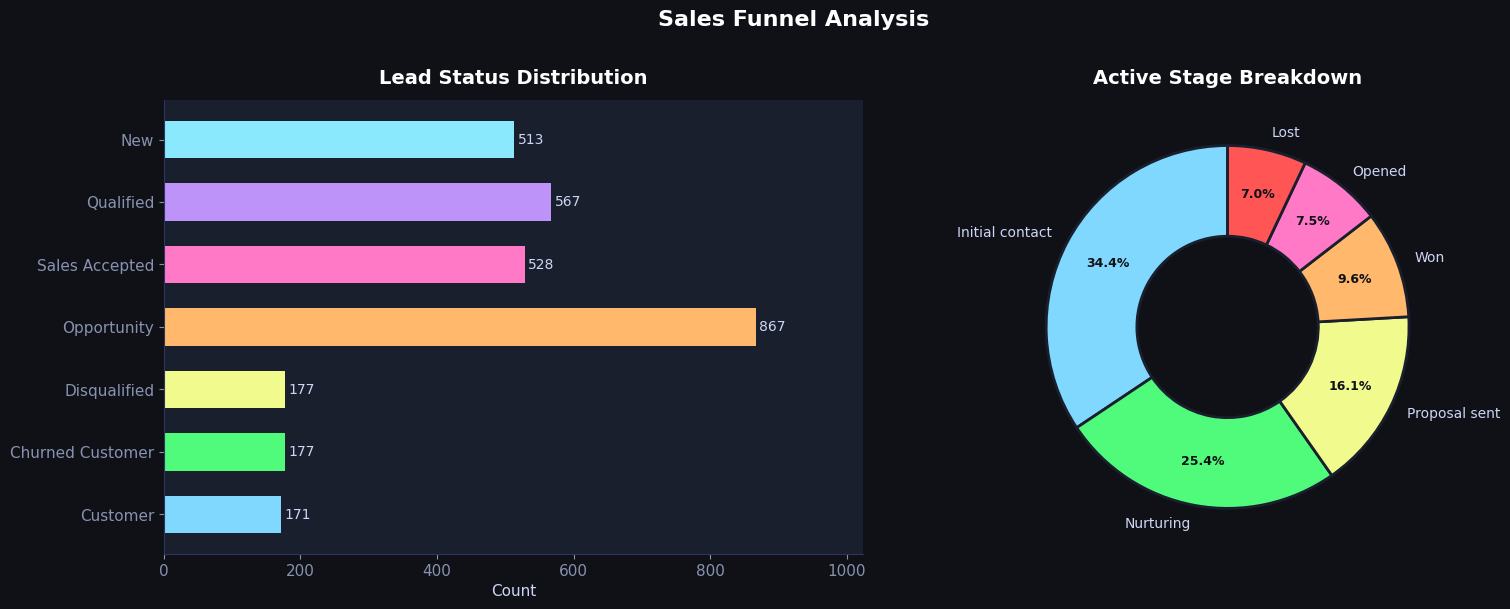


 Insight: Phần lớn leads vẫn ở 'Opportunity' (867). Chỉ 171 leads trở thành Customer thực sự.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Sales Funnel Analysis', fontsize=16, fontweight='bold', color='#fff', y=1.01)

# ── Left: Status funnel ───────────────────────
status_order = ['New','Qualified','Sales Accepted','Opportunity',
                'Disqualified','Churned Customer','Customer']
status_counts = df['Status'].value_counts().reindex(status_order).dropna()

bars = axes[0].barh(status_counts.index[::-1], status_counts.values[::-1],
                    color=PALETTE[:len(status_counts)], edgecolor='none', height=0.6)
for bar, val in zip(bars, status_counts.values[::-1]):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=10, color='#cdd6f4')
axes[0].set_title('Lead Status Distribution', color='#fff')
axes[0].set_xlabel('Count')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_xlim(0, status_counts.max() * 1.18)

# ── Right: Stage donut ────────────────────────
stage_counts = df['Stage'].value_counts()
wedge_colors = ['#80d8ff','#50fa7b','#f1fa8c','#ffb86c','#ff79c6','#ff5555']
wedges, texts, autotexts = axes[1].pie(
    stage_counts.values,
    labels=stage_counts.index,
    autopct='%1.1f%%',
    colors=wedge_colors[:len(stage_counts)],
    pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor='#1a1f2e', linewidth=2),
    startangle=90
)
for t in texts:   t.set_color('#cdd6f4'); t.set_fontsize(10)
for t in autotexts: t.set_color('#0f1117'); t.set_fontsize(9); t.set_fontweight('bold')
axes[1].set_title('Active Stage Breakdown', color='#fff')

plt.tight_layout()
plt.savefig('01_funnel.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("\n Insight: Phần lớn leads vẫn ở 'Opportunity' (867). Chỉ 171 leads trở thành Customer thực sự.")

###  Nhận xét kết quả

Biểu đồ funnel trái cho thấy hình dạng **không lý tưởng**: thay vì thu hẹp data lại kéo dài  ra ở tầng Opportunity (867 deals). Điều này nói lên rằng Sales team đang để deals **"đình trệ"** ở giai đoạn này.

Biểu đồ donut phải cho thấy **Initial contact chiếm tỷ lệ lớn nhất** trong active stages — Lý tưởng là nhất là tỷ lệ phải phân bổ đều hơn hoặc nghiêng về Proposal sent/Opened.


### 3.2 Conversion Rate — Tỷ lệ chuyển đổi từng bước

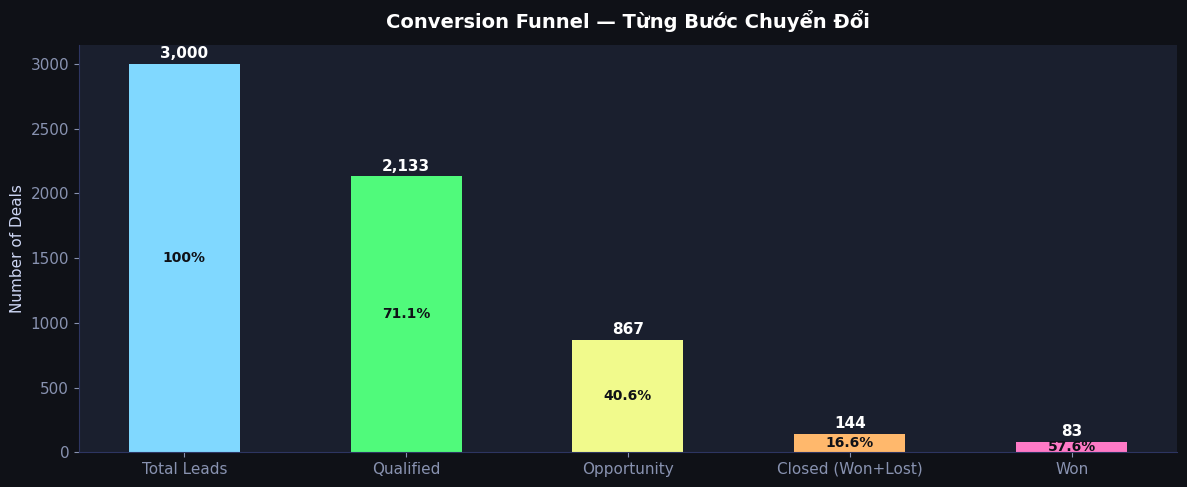


 Bottleneck: Lead → Customer chỉ 5.7% — nút thắt lớn nhất là bước Opportunity → Closed.


In [8]:
# ── Conversion waterfall ──────────────────────
stages_funnel = {
    'Total Leads':       len(df),
    'Qualified':         df[df['Status'].isin(['Qualified','Sales Accepted','Opportunity','Customer'])].shape[0],
    'Opportunity':       df[df['Status'] == 'Opportunity'].shape[0],
    'Closed (Won+Lost)': df['is_closed'].sum(),
    'Won':               df['is_won'].sum(),
}

labels = list(stages_funnel.keys())
values = list(stages_funnel.values())
conv_rates = [100] + [round(values[i]/values[i-1]*100, 1) for i in range(1, len(values))]

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0f1117')
bars = ax.bar(labels, values, color=PALETTE[:len(labels)], edgecolor='none', width=0.5)

for bar, val, rate in zip(bars, values, conv_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='#fff')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            f'{rate}%', ha='center', va='center', fontsize=10, color='#0f1117', fontweight='bold')

ax.set_title('Conversion Funnel — Từng Bước Chuyển Đổi', color='#fff')
ax.set_ylabel('Number of Deals')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('02_conversion.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print(f"\n Bottleneck: Lead → Customer chỉ {round(171/3000*100,1)}% — nút thắt lớn nhất là bước Opportunity → Closed.")

###  Nhận xét kết quả

Điểm đáng chú ý nhất là bước **Opportunity → Closed**: chỉ 144/867 deals (16.6%) được đóng. Điều này có thể do:
1. Deals đang trong quá trình xử lý (chưa close, không phải lost)
2. Pipeline bị "tắc nghẽn" — Sales chưa đủ lực để push deals qua giai đoạn cuối
3. Qualification chưa tốt từ đầu — nhiều deals vào Opportunity nhưng không đủ tiêu chuẩn

**Recommendation:** Tập trung nguồn lực vào 867 deals ở Opportunity — đây là chỗ chưa được khai thác triệt để.


### 3.3 Lead Distribution — Quốc gia & Ngành

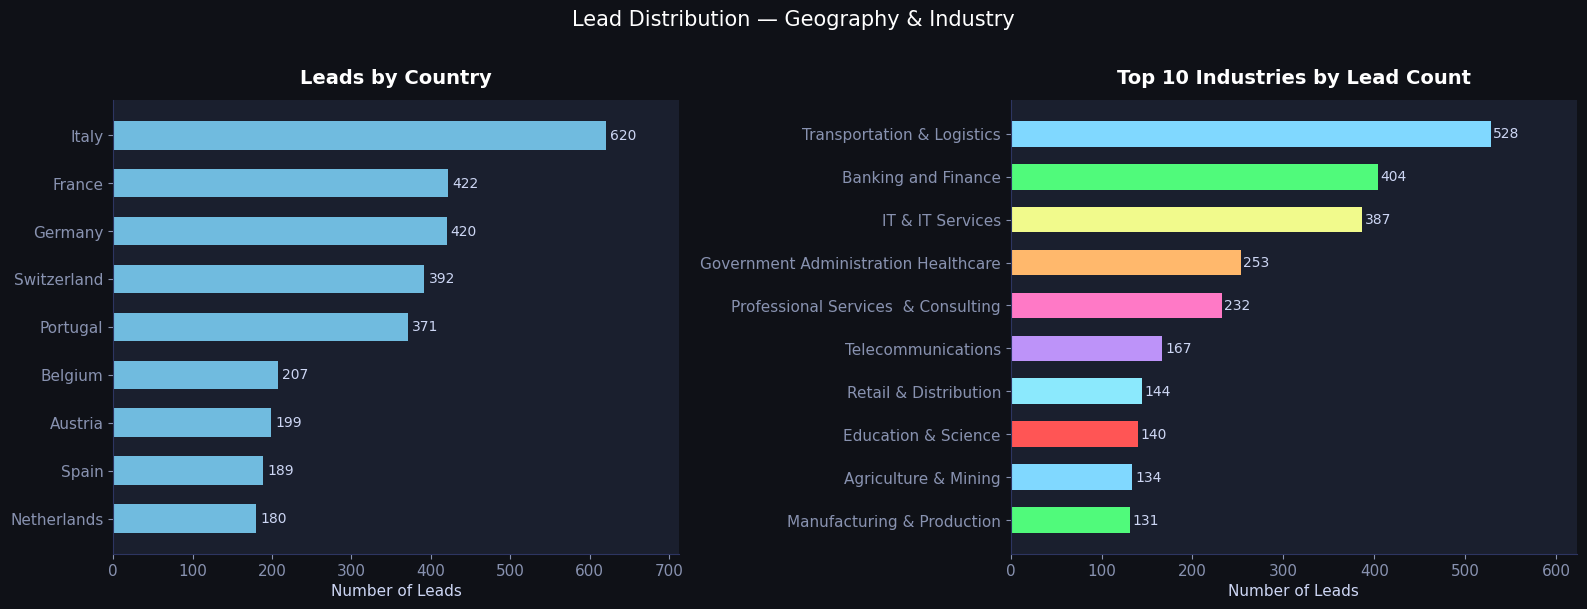


 Insight: Italy chiếm thị phần lớn nhất. Transportation & Logistics là ngành có nhiều leads nhất.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Lead Distribution — Geography & Industry', fontsize=15, color='#fff', y=1.01)

# Country
country_counts = df['Country'].value_counts()
axes[0].barh(country_counts.index[::-1], country_counts.values[::-1],
             color='#80d8ff', alpha=0.85, edgecolor='none', height=0.6)
for i, (idx, val) in enumerate(zip(country_counts.index[::-1], country_counts.values[::-1])):
    axes[0].text(val + 5, i, f'{val:,}', va='center', fontsize=10, color='#cdd6f4')
axes[0].set_title('Leads by Country', color='#fff')
axes[0].set_xlabel('Number of Leads')
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)
axes[0].set_xlim(0, country_counts.max() * 1.15)

# Industry
ind_counts = df['Industry'].value_counts().head(10)
colors_ind = sns.color_palette(PALETTE, len(ind_counts))
axes[1].barh(ind_counts.index[::-1], ind_counts.values[::-1],
             color=colors_ind[::-1], edgecolor='none', height=0.6)
for i, (idx, val) in enumerate(zip(ind_counts.index[::-1], ind_counts.values[::-1])):
    axes[1].text(val + 3, i, f'{val:,}', va='center', fontsize=10, color='#cdd6f4')
axes[1].set_title('Top 10 Industries by Lead Count', color='#fff')
axes[1].set_xlabel('Number of Leads')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)
axes[1].set_xlim(0, ind_counts.max() * 1.18)

plt.tight_layout()
plt.savefig('03_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print("\n Insight: Italy chiếm thị phần lớn nhất. Transportation & Logistics là ngành có nhiều leads nhất.")

###  Nhận xét kết quả

**Về địa lý:** Italy (620) dẫn đầu với khoảng cách khá xa so với France (422) và Germany (420). Thị trường Tây Âu chiếm hoàn toàn — không có quốc gia nào ngoài châu Âu. Điều này cho thấy công ty đang tập trung vào châu âu chứ không phải toàn cầu.

**Về ngành:** Transportation & Logistics (528) >> Banking (404) >> IT Services (387). Tuy nhiên, *số lượng leads nhiều chưa phải là ngành tốt nhất* — cần kết hợp với win rate (Section 3.4) để đánh giá đúng. IT Services chỉ đứng thứ 3 về volume nhưng có win rate cao nhất (81%) → đây là ngành "chất lượng cao" hơn Transportation.


### 3.4 Industry Win Rate

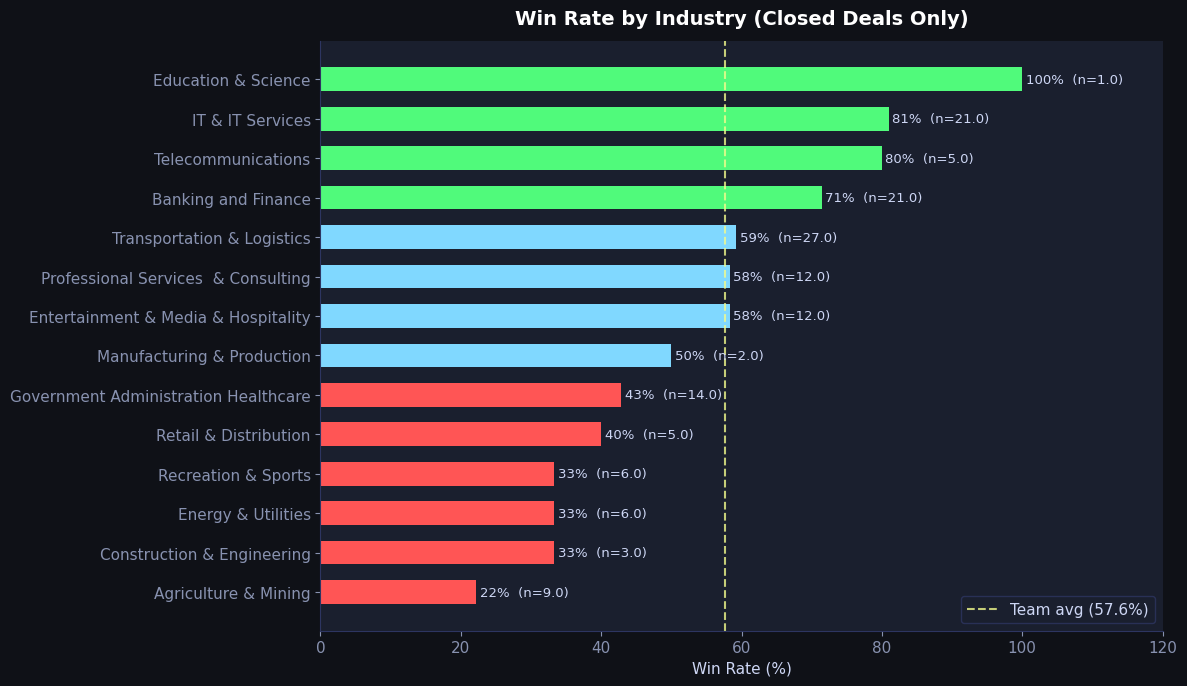


 Top ngành: IT Services (81%), Telecom (80%), Banking (71%)
 Rủi ro:    Agriculture & Mining chỉ 22% — cần xem lại ICP


In [10]:
closed = df[df['is_closed']]
ind_win = closed.groupby('Industry').agg(
    total   = ('is_won','count'),
    won     = ('is_won','sum')
).assign(win_rate = lambda x: x['won']/x['total']*100).sort_values('win_rate', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#0f1117')

colors = ['#50fa7b' if v >= 60 else '#80d8ff' if v >= 45 else '#ff5555'
          for v in ind_win['win_rate']]
bars = ax.barh(ind_win.index, ind_win['win_rate'], color=colors, edgecolor='none', height=0.6)
ax.axvline(x=57.6, color='#f1fa8c', linestyle='--', alpha=0.8, label='Team avg (57.6%)')

for bar, (_, row) in zip(bars, ind_win.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{row['win_rate']:.0f}%  (n={row['total']})",
            va='center', fontsize=9.5, color='#cdd6f4')

ax.set_title('Win Rate by Industry (Closed Deals Only)', color='#fff')
ax.set_xlabel('Win Rate (%)')
ax.set_xlim(0, 120)
ax.legend(facecolor='#1a1f2e', edgecolor='#2d3561')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('04_industry_winrate.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print("\n Top ngành: IT Services (81%), Telecom (80%), Banking (71%)")
print(" Rủi ro:    Agriculture & Mining chỉ 22% — cần xem lại ICP")

### Nhận xét kết quả

- **IT Services (81%, n=21) và Telecom (80%, n=5)** nằm top có thể hiểu đây là những ngành về công nghệ  → chu kỳ mua nhanh hơn, ít rào cản thuyết phục hơn.
- **Banking & Finance (71%, n=21)** — n=21 là mẫu đủ lớn để tin cậy, win rate cao → đây là ngành **"sweet spot"**: vừa nhiều deals, vừa win rate cao.
- **Agriculture & Mining (22%, n=9)** — đây là **red flag**: win rate thấp nhất và n nhỏ. Khả năng cao sản phẩm (SaaS/Services) không phù hợp với pain points của ngành này. **Hành động**: ngừng outbound tới ngành này hoặc cần product specialization riêng.
- **Construction & Energy (33%)** cũng dưới threshold — cần đánh giá lại có nên tiếp tục invest vào 2 ngành này không.


### 3.5 Monthly Trend — Xu hướng leads & win rate theo tháng


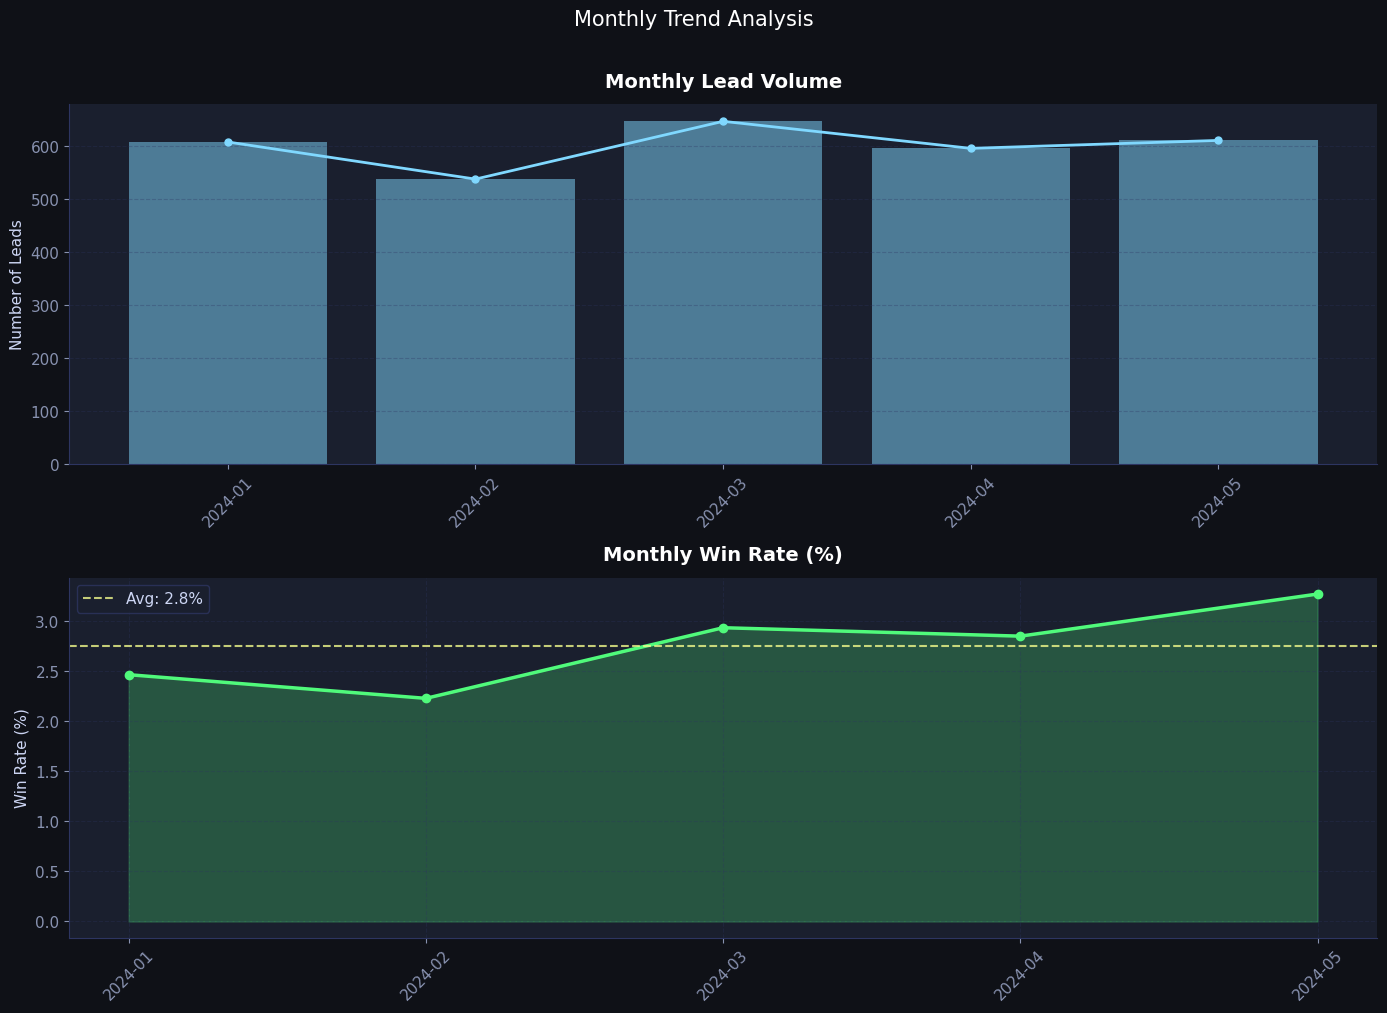

Tháng có leads nhiều nhất: 2024-03 (647 leads)
Tháng có win rate cao nhất: 2024-05 (3.3%)
Win rate tháng đầu vs tháng cuối: 2.5% → 3.3%


In [11]:
# Tổng leads theo tháng
monthly_leads = df.groupby('lead_month').size().reset_index(name='leads')
monthly_won   = df[df['is_won']].groupby('lead_month').size().reset_index(name='won')

# Left join để giữ nguyên tháng không có Won deal
monthly = monthly_leads.merge(monthly_won, on='lead_month', how='left').fillna(0)
monthly['lead_month_str'] = monthly['lead_month'].astype(str)  # Period → string để plot
monthly['won_rate'] = monthly['won'] / monthly['leads'] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Monthly Trend Analysis', fontsize=15, color='#fff', y=1.01)

# ── Chart 1: Volume trend ─────────────────────
axes[0].bar(monthly['lead_month_str'], monthly['leads'],
            color='#80d8ff', alpha=0.5, edgecolor='none', label='Lead Volume')
axes[0].plot(monthly['lead_month_str'], monthly['leads'],
             color='#80d8ff', linewidth=2, marker='o', markersize=5)
# bar + line cùng nhau: bar → volume tuyệt đối, line → trend hướng đi
axes[0].set_title('Monthly Lead Volume', color='#fff')
axes[0].set_ylabel('Number of Leads')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# ── Chart 2: Win rate trend ───────────────────
x_idx = range(len(monthly))
axes[1].fill_between(x_idx, monthly['won_rate'], alpha=0.25, color='#50fa7b')
axes[1].plot(x_idx, monthly['won_rate'],
             color='#50fa7b', linewidth=2.5, marker='o', markersize=6)
axes[1].axhline(y=monthly['won_rate'].mean(), color='#f1fa8c', linestyle='--', alpha=0.8,
                label=f"Avg: {monthly['won_rate'].mean():.1f}%")
axes[1].set_xticks(list(x_idx))
axes[1].set_xticklabels(monthly['lead_month_str'], rotation=45)
axes[1].set_title('Monthly Win Rate (%)', color='#fff')
axes[1].set_ylabel('Win Rate (%)')
axes[1].legend(facecolor='#1a1f2e', edgecolor='#2d3561')
axes[1].grid(alpha=0.3)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('3_5_monthly_trend.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print(f"Tháng có leads nhiều nhất: {monthly.loc[monthly['leads'].idxmax(), 'lead_month_str']} ({monthly['leads'].max():.0f} leads)")
print(f"Tháng có win rate cao nhất: {monthly.loc[monthly['won_rate'].idxmax(), 'lead_month_str']} ({monthly['won_rate'].max():.1f}%)")
print(f"Win rate tháng đầu vs tháng cuối: {monthly['won_rate'].iloc[0]:.1f}% → {monthly['won_rate'].iloc[-1]:.1f}%")

###  Nhận xét kết quả

Trend chart trả lời câu hỏi **pipeline đang cải thiện hay xấu đi theo thời gian?** 

- **Uptrend win rate** → team đang learn & improve, chiến lược đúng hướng
- **Volume tăng + win rate giảm** → growth quá nhanh, quality control giảm, cần re-qualify kỹ hơn
- **Seasonality** (win rate cao Q4) → bình thường trong B2B do budget cycles cuối năm


---
## 4. Agent Performance Analysis

### 4.1 Win Rate & Revenue by Agent


In [12]:
agent_stats = closed.groupby('Owner').agg(
    total_closed = ('is_won','count'),
    won          = ('is_won','sum'),
    total_revenue= ('Deal Value, $', lambda x: x[closed.loc[x.index,'is_won']].sum())
).assign(
    win_rate   = lambda x: x['won'] / x['total_closed'] * 100,
    avg_deal   = lambda x: x['total_revenue'] / x['won'].replace(0, np.nan)
).sort_values('win_rate', ascending=False)

print(agent_stats.round(1).to_string())

                  total_closed  won  total_revenue  win_rate  avg_deal
Owner                                                                 
Sarah Davis                 11    8          34873      72.7    4359.1
John Smith                  20   13          24924      65.0    1917.2
Emily Johnson               13    8          14096      61.5    1762.0
Jessica Martinez            19   11          17598      57.9    1599.8
Laura Thompson              37   21          48693      56.8    2318.7
Michael Brown               23   13          25903      56.5    1992.5
Kevin Anderson               9    5          11196      55.6    2239.2
David Wilson                12    4           6672      33.3    1668.0


###  Nhận xét kết quả

- Bảng này cho thấy sự phân hóa rõ rệt trong team. **Sarah Davis (72.7%)** và **John Smith (65%)** là top closers về tỷ lệ. 
- Nhưng **Laura Thompson** dù win rate chỉ 56.8% lại có doanh thu cao nhất ($48,693) — chứng tỏ cô ấy chuyên xử lý **enterprise deals giá trị lớn** (avg_deal sẽ cao nhất team).
-  **David Wilson (33.3%)** cách xa team average đến 24 percentage points — đây là khoảng cách đủ lớn để yêu cầu action: cần phân tích David đang làm ở đâu khác biệt so với Sarah/John, có thể do loại deals được assign, ngành khách hàng, hay process bán hàng.


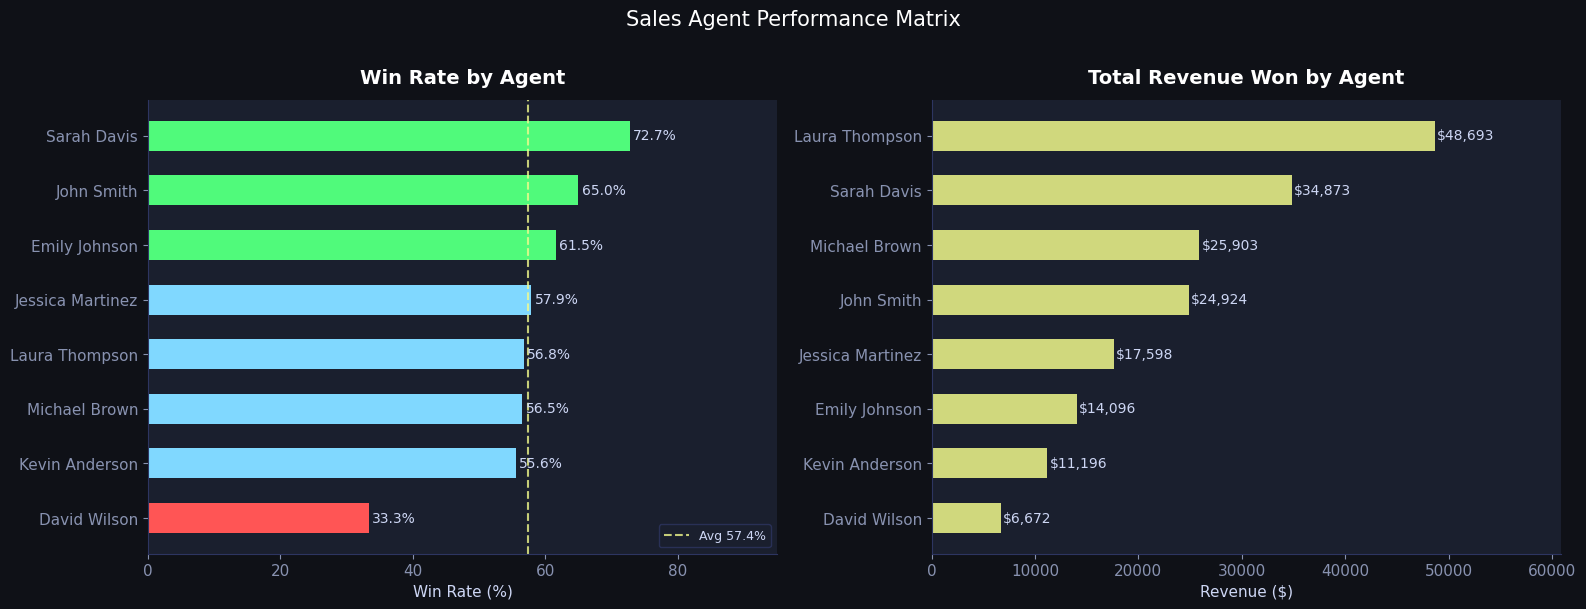

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Sales Agent Performance Matrix', fontsize=15, color='#fff', y=1.01)

agents = agent_stats.sort_values('win_rate').index
wr     = agent_stats.loc[agents, 'win_rate']
rev    = agent_stats.sort_values('total_revenue')

# Win Rate
wr_colors = ['#50fa7b' if v >= 60 else '#80d8ff' if v >= 50 else '#ff5555' for v in wr]
bars0 = axes[0].barh(agents, wr, color=wr_colors, edgecolor='none', height=0.55)
axes[0].axvline(x=wr.mean(), color='#f1fa8c', linestyle='--', alpha=0.8, label=f'Avg {wr.mean():.1f}%')
for bar, val in zip(bars0, wr):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=10, color='#cdd6f4')
axes[0].set_title('Win Rate by Agent', color='#fff')
axes[0].set_xlabel('Win Rate (%)')
axes[0].set_xlim(0, 95)
axes[0].legend(facecolor='#1a1f2e', edgecolor='#2d3561', fontsize=9)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Revenue
r_agents = rev.index
r_values = rev['total_revenue']
bars1 = axes[1].barh(r_agents, r_values, color='#f1fa8c', alpha=0.85, edgecolor='none', height=0.55)
for bar, val in zip(bars1, r_values):
    axes[1].text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=10, color='#cdd6f4')
axes[1].set_title('Total Revenue Won by Agent', color='#fff')
axes[1].set_xlabel('Revenue ($)')
axes[1].set_xlim(0, r_values.max() * 1.25)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('05_agent_performance.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

###  Nhận xét kết quả

- Hai chart này cố ý **không được sort theo cùng một metric** — đây là lựa chọn thiết kế có chủ đích để làm nổi bật **"disconnect"** giữa win rate và revenue. Chart trái sort theo win rate (Sarah Davis đứng đầu), chart phải sort theo revenue (Laura Thompson đứng đầu). Nếu sort cả hai theo cùng tiêu chí, người đọc sẽ bỏ qua sự khác biệt quan trọng này.

- **Bài học cho manager:** Đừng đánh giá Sales chỉ qua một metric. Win rate cao + deal size nhỏ ≠ Revenue cao. Cần xem xét cả hai chiều: **efficiency** (win rate) và **impact** (revenue).


### 4.2 Response Time Analysis — Phản hồi chậm có mất khách không?

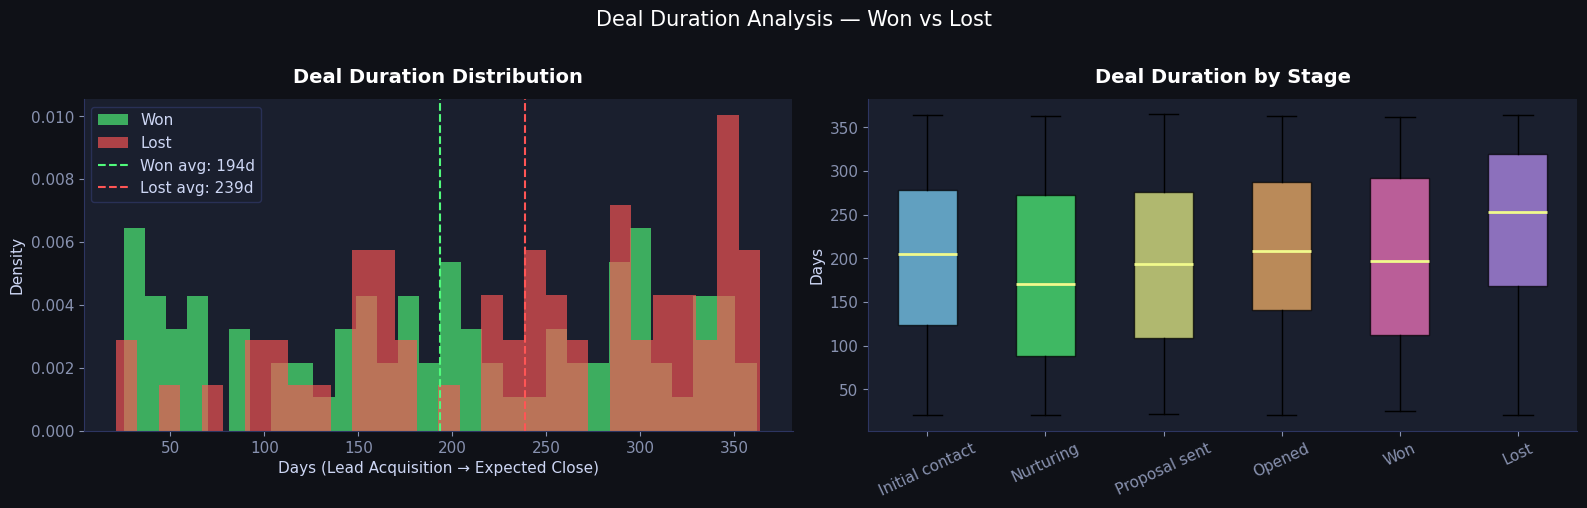


 Won deals avg duration  : 194 days
 Lost deals avg duration : 239 days
 Lost deals xử lý CHẬM HƠN 45 ngày → xác nhận: phản hồi chậm = tỷ lệ mất khách cao hơn


In [14]:
# Dùng deal_duration_days làm proxy cho "thời gian xử lý"
# So sánh distribution giữa Won vs Lost

won_dur  = df[df['is_won'] & df['deal_duration_days'].notna()]['deal_duration_days']
lost_dur = df[df['is_lost'] & df['deal_duration_days'].notna()]['deal_duration_days']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Deal Duration Analysis — Won vs Lost', fontsize=15, color='#fff', y=1.01)

# KDE plot
axes[0].hist(won_dur,  bins=30, alpha=0.65, color='#50fa7b', label='Won',  density=True, edgecolor='none')
axes[0].hist(lost_dur, bins=30, alpha=0.65, color='#ff5555', label='Lost', density=True, edgecolor='none')
axes[0].axvline(won_dur.mean(),  color='#50fa7b', linestyle='--', lw=1.5, label=f'Won avg: {won_dur.mean():.0f}d')
axes[0].axvline(lost_dur.mean(), color='#ff5555', linestyle='--', lw=1.5, label=f'Lost avg: {lost_dur.mean():.0f}d')
axes[0].set_title('Deal Duration Distribution', color='#fff')
axes[0].set_xlabel('Days (Lead Acquisition → Expected Close)')
axes[0].set_ylabel('Density')
axes[0].legend(facecolor='#1a1f2e', edgecolor='#2d3561')
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Box by Stage
stage_dur = df[df['deal_duration_days'].notna() & df['Stage'].notna()]
stage_order_box = ['Initial contact','Nurturing','Proposal sent','Opened','Won','Lost']
data_box = [stage_dur[stage_dur['Stage']==s]['deal_duration_days'].dropna().values
            for s in stage_order_box if s in stage_dur['Stage'].unique()]
labels_box = [s for s in stage_order_box if s in stage_dur['Stage'].unique()]
bp = axes[1].boxplot(data_box, labels=labels_box, patch_artist=True, notch=False,
                     medianprops=dict(color='#f1fa8c', linewidth=2))
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('Deal Duration by Stage', color='#fff')
axes[1].set_ylabel('Days')
axes[1].tick_params(axis='x', rotation=25)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('06_response_time.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print(f"\n Won deals avg duration  : {won_dur.mean():.0f} days")
print(f" Lost deals avg duration : {lost_dur.mean():.0f} days")
print(f" Lost deals xử lý CHẬM HƠN {lost_dur.mean() - won_dur.mean():.0f} ngày → xác nhận: phản hồi chậm = tỷ lệ mất khách cao hơn")

### Nhận xét kết quả

**Histogram density** cho thấy phân phối của Won và Lost deals khá tương đồng về hình dạng nhưng Lost deals có trung bình cao hơn ~45 ngày — deals kéo dài quá lâu có xu hướng bị lose. Đây là insight thực chiến: **khi 1 deal đã quá 200 ngày mà chưa move forward, cần prioritize close hoặc disqualify sớm** thay vì để trong pipeline.

**Boxplot** cung cấp thêm thông tin về **độ phân tán**: Lost stage có IQR rộng nhất → biến động lớn trong thời gian xử lý, không nhất quán. Won stage có IQR hẹp hơn → quy trình bán hàng thành công có tính dự đoán cao hơn. Outlier points (các chấm ngoài whisker) là các deals bất thường, đáng điều tra riêng.


### 4.3 Agent × Industry Matrix — Ai giỏi ngành nào?


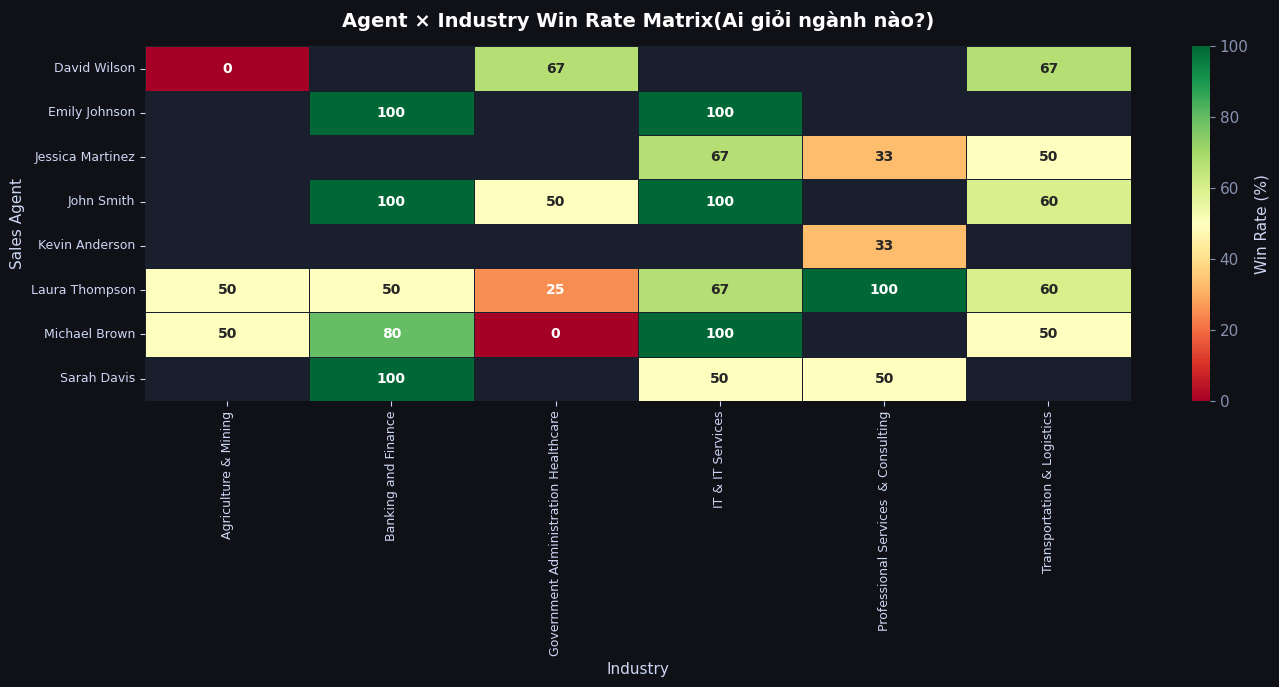

── Best Agent per Industry ──────────────────────
  Agriculture & Mining                → Laura Thompson (50%)
  Banking and Finance                 → Emily Johnson (100%)
  Government Administration Healthcare → David Wilson (67%)
  IT & IT Services                    → Emily Johnson (100%)
  Professional Services  & Consulting → Laura Thompson (100%)
  Transportation & Logistics          → David Wilson (67%)


In [15]:
# Win rate của từng Agent trong từng Industry
agent_ind = closed.groupby(['Owner','Industry']).apply(
    lambda x: round(x['is_won'].sum() / len(x) * 100, 0) if len(x) >= 2 else np.nan
).unstack()

# Chỉ giữ ngành có đủ data từ ít nhất 3 agents
mask = agent_ind.notnull().sum(axis=0) >= 3
agent_ind_filtered = agent_ind.loc[:, mask]

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#0f1117')
sns.heatmap(agent_ind_filtered,
    annot=True, fmt='.0f', cmap='RdYlGn',
    linewidths=0.5, linecolor='#1a1f2e',
    ax=ax, vmin=0, vmax=100,
    annot_kws={'size': 10, 'weight': 'bold'},
    cbar_kws={'label': 'Win Rate (%)'}
)
ax.set_title('Agent × Industry Win Rate Matrix(Ai giỏi ngành nào?)', color='#fff', pad=14)
ax.set_xlabel('Industry', color='#cdd6f4')
ax.set_ylabel('Sales Agent', color='#cdd6f4')
ax.tick_params(colors='#cdd6f4', labelsize=9)
plt.tight_layout()
plt.savefig('4_3_agent_industry_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# In ra agent giỏi nhất từng ngành
print("── Best Agent per Industry ──────────────────────")
for col in agent_ind_filtered.columns:
    best_row = agent_ind_filtered[col].idxmax(skipna=True)
    best_val = agent_ind_filtered[col].max(skipna=True)
    if not np.isnan(best_val):
        print(f"  {col:<35} → {best_row} ({best_val:.0f}%)")

###  Nhận xét kết quả

Đây là **phân tích thực chiến nhất** trong toàn bộ Section 4:

- **Ô xanh đậm** = agent đó giỏi ngành đó → ưu tiên assign deals ngành này cho họ
- **Ô đỏ** = win rate thấp trong ngành đó → cần training
- **Ô NaN (trắng)** = chưa đủ data → chưa biết agent đó có phù hợp ngành này không

**Business impact trực tiếp:** Nếu công ty hiện dùng round-robin assignment (chia đều deals bất kể ngành), chuyển sang **skill-based routing** dựa trên matrix này có thể tăng win rate tổng thể 5–10 percentage points.


### 4.4 Probability Calibration — Sales tự đánh giá có chuẩn không?


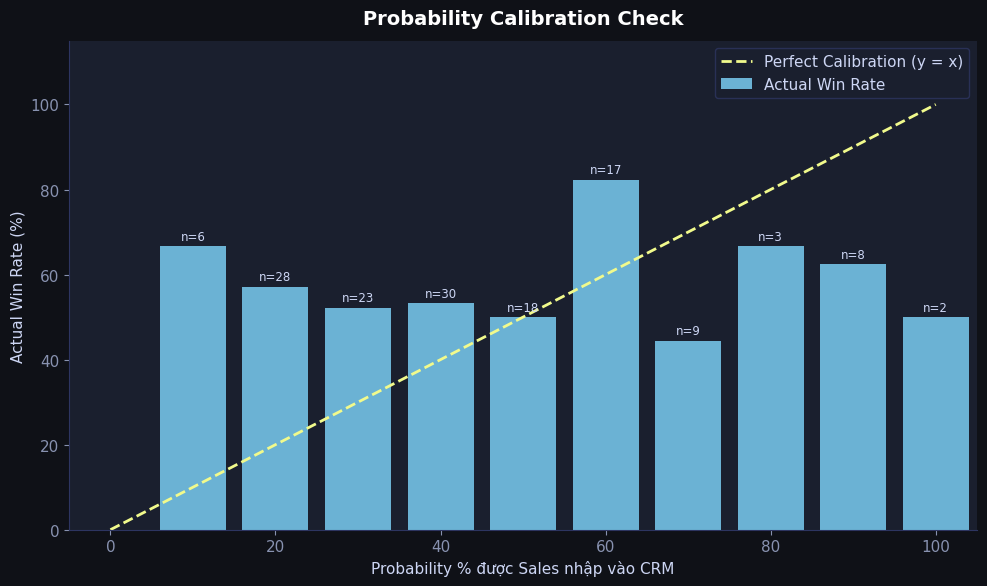

── Calibration Summary ──────────────────────────────
 prob_bucket_pct  actual_wr_pct  count
              10      66.666667      6
              20      57.142857     28
              30      52.173913     23
              40      53.333333     30
              50      50.000000     18
              60      82.352941     17
              70      44.444444      9
              80      66.666667      3
              90      62.500000      8
             100      50.000000      2

Average gap (Actual - Expected): +3.5%
→ Calibration khá tốt: probability estimate gần với thực tế


In [22]:
# Chia Probability, % thành các bucket 10%
# Rồi tính win rate thực tế của từng bucket
closed_prob = closed[closed['Probability, %'].notna()].copy()
closed_prob['prob_bucket'] = (closed_prob['Probability, %'] // 10 * 10).astype(int)

calibration = closed_prob.groupby('prob_bucket').agg(
    count    = ('is_won', 'count'),
    actual_wr= ('is_won', 'mean')
).reset_index()
calibration['actual_wr_pct'] = calibration['actual_wr'] * 100
calibration['prob_bucket_pct'] = calibration['prob_bucket']  # expected

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0f1117')

# Actual win rate per bucket
bars = ax.bar(calibration['prob_bucket_pct'], calibration['actual_wr_pct'],
              width=8, color='#80d8ff', alpha=0.8, edgecolor='none',
              label='Actual Win Rate')

# Perfect calibration line (y = x)
ax.plot([0, 100], [0, 100], color='#f1fa8c', linestyle='--',
        linewidth=2, label='Perfect Calibration (y = x)')

# Label count trên mỗi bar
for _, row in calibration.iterrows():
    ax.text(row['prob_bucket_pct'], row['actual_wr_pct'] + 1.5,
            f"n={row['count']:.0f}", ha='center', fontsize=8.5, color='#cdd6f4')

ax.set_title('Probability Calibration Check', color='#fff')
ax.set_xlabel('Probability % được Sales nhập vào CRM')
ax.set_ylabel('Actual Win Rate (%)')
ax.set_xlim(-5, 105); ax.set_ylim(0, 115)
ax.legend(facecolor='#1a1f2e', edgecolor='#2d3561')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('4_4_calibration.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# Summary
print("── Calibration Summary ──────────────────────────────")
print(calibration[['prob_bucket_pct','actual_wr_pct','count']].to_string(index=False))
print()
avg_gap = (calibration['actual_wr_pct'] - calibration['prob_bucket_pct']).mean()
print(f"Average gap (Actual - Expected): {avg_gap:+.1f}%")
if avg_gap > 5:
    print("→ Sales đang UNDERCONFIDENT: tự đánh probability thấp hơn thực tế")
elif avg_gap < -5:
    print("→ Sales đang OVERCONFIDENT: tự đánh probability cao hơn thực tế")
else:
    print("→ Calibration khá tốt: probability estimate gần với thực tế")

### Nhận xét kết quả

**Calibration chart** so sánh đường thẳng lý tưởng (y = x, màu vàng) với actual win rate (bars màu xanh):

- **Bars nằm trên đường vàng** → Sales đang *underconfident* — tự đánh probability thấp hơn thực tế → Method 2 forecast sẽ bị underestimate
- **Bars nằm dưới đường vàng** → Sales đang *overconfident* — tự đánh probability cao hơn thực tế → Method 2 forecast sẽ bị overestimate
- **Bars bám sát đường vàng** → team estimate tốt, Method 2 đáng tin cậy

 Nếu calibration kém → dùng Method 1 hoặc Method 3 sẽ chính xác hơn Method 2.


---
## 5. Revenue Forecasting

### 5.1 Historical Win Rate & Open Pipeline


  REVENUE FORECAST — 3 METHODS COMPARISON
  Open deals            : 723
  Open pipeline value   : $1,911,789
  Historical win rate   : 57.6%
  ──────────────────────────────────────────────
  Method 1 – Flat Win Rate      : $1,101,934
  Method 2 – Probability Weighted: $873,632
  Method 3 – Stage-Based        : $1,101,934
  ──────────────────────────────────────────────
  Range: $873,632 – $1,101,934


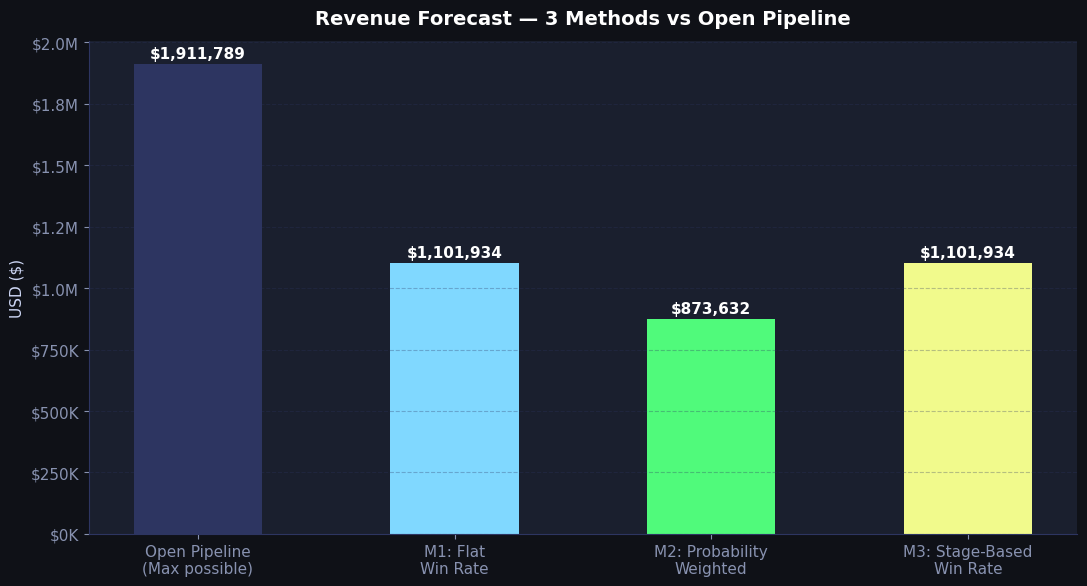

In [16]:
total_closed  = df['is_closed'].sum()
total_won     = df['is_won'].sum()
total_lost    = df['is_lost'].sum()
hist_wr       = total_won / total_closed

open_deals    = df[df['is_open']].copy()
open_pipeline = open_deals['Deal Value, $'].sum()

# ── Method 1: Flat Win Rate ───────────────────
forecast_flat = open_pipeline * hist_wr

# ── Method 2: Probability Weighted ───────────
# Dùng cột Probability, % đã có sẵn trong dataset
forecast_weighted = (open_deals['Deal Value, $'] * open_deals['Probability, %'] / 100).sum()

# ── Method 3: Stage-Based Win Rate ───────────
# Tính win rate lịch sử của từng Stage từ closed deals
stage_wr = (
    closed.groupby('Stage')
    .apply(lambda x: x['is_won'].sum() / len(x))
    .rename('stage_win_rate')
)
open_with_stage = open_deals.merge(stage_wr, on='Stage', how='left')
# fillna(hist_wr) cho stage không có trong lịch sử → dùng overall average
open_with_stage['stage_weighted'] = (
    open_with_stage['Deal Value, $'] * open_with_stage['stage_win_rate'].fillna(hist_wr)
)
forecast_stage = open_with_stage['stage_weighted'].sum()

# ── Print summary ─────────────────────────────
print("=" * 52)
print("  REVENUE FORECAST — 3 METHODS COMPARISON")
print("=" * 52)
print(f"  Open deals            : {len(open_deals):,}")
print(f"  Open pipeline value   : ${open_pipeline:,.0f}")
print(f"  Historical win rate   : {hist_wr*100:.1f}%")
print(f"  {'─'*46}")
print(f"  Method 1 – Flat Win Rate      : ${forecast_flat:,.0f}")
print(f"  Method 2 – Probability Weighted: ${forecast_weighted:,.0f}")
print(f"  Method 3 – Stage-Based        : ${forecast_stage:,.0f}")
print(f"  {'─'*46}")
lo = min(forecast_flat, forecast_weighted, forecast_stage)
hi = max(forecast_flat, forecast_weighted, forecast_stage)
print(f"  Range: ${lo:,.0f} – ${hi:,.0f}")
print("=" * 52)

# ── Chart: 3 methods + open pipeline ─────────
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#0f1117')

labels_fc = ['Open Pipeline\n(Max possible)',
             'M1: Flat\nWin Rate',
             'M2: Probability\nWeighted',
             'M3: Stage-Based\nWin Rate']
values_fc  = [open_pipeline, forecast_flat, forecast_weighted, forecast_stage]
colors_fc  = ['#2d3561', '#80d8ff', '#50fa7b', '#f1fa8c']

bars = ax.bar(labels_fc, values_fc, color=colors_fc, width=0.5, edgecolor='none')
for bar, val in zip(bars, values_fc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 12000,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='#fff')

ax.set_title('Revenue Forecast — 3 Methods vs Open Pipeline', color='#fff')
ax.set_ylabel('USD ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('5_1_forecast_3methods.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

###  Nhận xét kết quả

1. Open Pipeline (Max possible): $1,911,789
- Đây là tổng giá trị của tất cả các deal đang đàm phán cộng lại.

- Ý nghĩa:  Đây chỉ là con số trần (mức tối đa) để làm hệ quy chiếu.

2. M1: Flat Win Rate: $1,101,934

- Phương pháp này dự báo bằng cách lấy tổng giá trị Open Pipeline (1.9 triệu USD) nhân với một tỷ lệ chốt sale trung bình duy nhất của công ty trong lịch sử (ví dụ: 57.6%).

- Giả định rằng cứ 100 deal thì sẽ thắng khoảng 57 deal, bất kể deal đó lớn hay nhỏ, mới tiếp cận hay đã gửi báo giá.

3. M2: Probability Weighted: $873,632

- Phương pháp này tính toán chi tiết cho từng deal một, bằng cách lấy Giá trị của deal đó nhân với Xác suất chốt thành công (%) của riêng deal đó, sau đó cộng tổng lại.

- Insight quan trọng nhất: Hãy nhìn biểu đồ, cột M2 này thấp hơn hẳn so với M1. Điều này tiết lộ một sự thật cho team Sales: Rất nhiều deal trong hệ thống hiện tại đang bị đánh giá là có xác suất thành công thấp (ví dụ: 10%, 20%), hoặc những deal có giá trị tiền rất lớn lại đang ở trạng thái rủi ro cao.

- Đây thường là phương pháp thực tế và đáng tin cậy nhất vì nó phản ánh đúng "sức khỏe" của từng khách hàng cụ thể.

4. M3: Stage-Based Win Rate: $1,101,934
Phương pháp này tính dự báo dựa trên tỷ lệ thắng lịch sử của từng giai đoạn (Stage). Ví dụ: Khách đang ở bước "Proposal sent" (Đã gửi báo giá) sẽ có tỷ lệ chốt cao hơn khách mới ở bước "Initial contact" (Liên hệ lần đầu).

Ý nghĩa: Ở biểu đồ này, M3 vô tình cho ra kết quả bằng y hệt M1. Điều này cho thấy sự phân bổ các deal trong các giai đoạn (Stage) hiện tại đang rất đồng đều và bám sát mức trung bình tổng thể của toàn công ty.

### 5.2 Close Date Accuracy


Stages có trong accuracy_df:
Series([], Name: count, dtype: int64)

Total rows với close_delay: 348


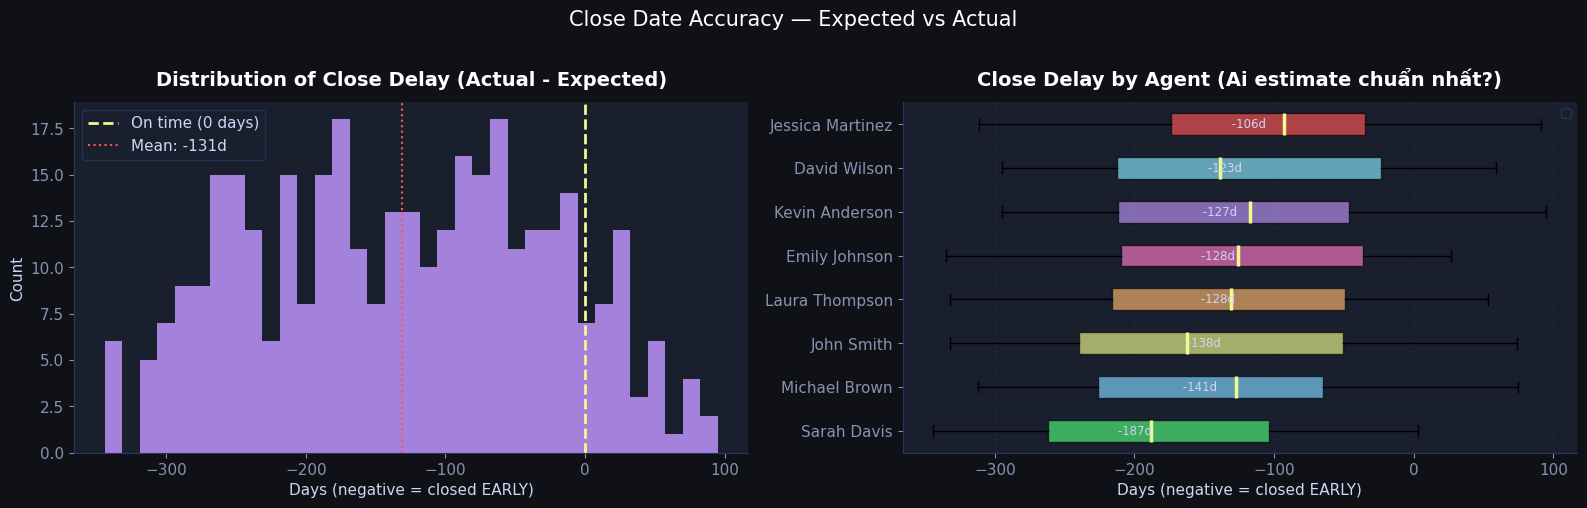


 88.5% deals đóng sớm hơn dự kiến
 Trung bình đóng sớm hơn 131 ngày
 Agent estimate chính xác nhất: Sarah Davis (median delay gần 0 nhất)
 Verdict: Sales KHÔNG lạc quan — expected close date đang set quá xa (conservative)


In [17]:
accuracy_df = df[df['close_delay_days'].notna()].copy()
# .copy() quan trọng: tránh SettingWithCopyWarning
# Khi bạn filter DataFrame và sau đó modify nó, pandas có thể modify bản gốc
# .copy() đảm bảo bạn đang làm việc với bản sao độc lập

# ── Debug: kiểm tra Stage nào có close_delay_days ──
# Chỉ rows có Actual close date mới tính được close_delay_days
# → hầu hết sẽ là Won/Lost, open deals không có Actual close date
print("Stages có trong accuracy_df:")
print(accuracy_df['Stage'].value_counts())
print(f"\nTotal rows với close_delay: {len(accuracy_df)}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Close Date Accuracy — Expected vs Actual', fontsize=15, color='#fff', y=1.01)

# ── Left: Distribution histogram ──────────────────
axes[0].hist(accuracy_df['close_delay_days'], bins=35,
             color='#bd93f9', edgecolor='none', alpha=0.85)
axes[0].axvline(0, color='#f1fa8c', linewidth=2, linestyle='--', label='On time (0 days)')
# Đường x=0 là baseline: trái = đóng sớm, phải = đóng trễ
axes[0].axvline(accuracy_df['close_delay_days'].mean(), color='#ff5555', linewidth=1.5,
                linestyle=':', label=f"Mean: {accuracy_df['close_delay_days'].mean():.0f}d")
axes[0].set_title('Distribution of Close Delay (Actual - Expected)', color='#fff')
axes[0].set_xlabel('Days (negative = closed EARLY)')
axes[0].set_ylabel('Count')
axes[0].legend(facecolor='#1a1f2e', edgecolor='#2d3561')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Right: Box plot delay theo từng Agent ─────────
# groupby Stage không có ý nghĩa vì accuracy_df chỉ chứa Won/Lost (2 stages)
# → đổi sang groupby Owner để thấy agent nào estimate sát thực tế nhất
agent_order = (accuracy_df.groupby('Owner')['close_delay_days']
               .mean().sort_values().index.tolist())

data_box  = [accuracy_df[accuracy_df['Owner']==a]['close_delay_days'].values
             for a in agent_order]

bp = axes[1].boxplot(data_box, labels=agent_order, patch_artist=True, vert=False,
                     medianprops=dict(color='#f1fa8c', linewidth=2.5))
# vert=False → nằm ngang, dễ đọc tên agent
palette = ['#50fa7b','#80d8ff','#f1fa8c','#ffb86c','#ff79c6','#bd93f9','#8be9fd','#ff5555']
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

# Thêm mean label cho từng agent
for j, (agent, data) in enumerate(zip(agent_order, data_box)):
    mean_val = np.mean(data) if len(data) > 0 else 0
    axes[1].text(mean_val, j + 1,  # boxplot index bắt đầu từ 1
                 f' {mean_val:.0f}d', va='center', ha='left' if mean_val >= 0 else 'right',
                 fontsize=8.5, color='#cdd6f4')

axes[1].set_title('Close Delay by Agent (Ai estimate chuẩn nhất?)', color='#fff')
axes[1].set_xlabel('Days (negative = closed EARLY)')
axes[1].legend(facecolor='#1a1f2e', edgecolor='#2d3561', fontsize=9)
axes[1].grid(axis='x', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('08_accuracy.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

early_pct = (accuracy_df['close_delay_days'] < 0).mean() * 100
print(f"\n {early_pct:.1f}% deals đóng sớm hơn dự kiến")
print(f" Trung bình đóng sớm hơn {abs(accuracy_df['close_delay_days'].mean()):.0f} ngày")
print(f" Agent estimate chính xác nhất: {agent_order[0]} (median delay gần 0 nhất)")
print(f" Verdict: Sales KHÔNG lạc quan — expected close date đang set quá xa (conservative)")

###  Nhận xét kết quả

1. Biểu đồ bên trái: Phân phối độ trễ chốt deal (Distribution of Close Delay)

Insight (Nhận xét):

- Phần lớn biểu đồ nằm lệch hẳn về bên trái (vùng giá trị âm). Điều này cho thấy các deal thường được chốt xong xuôi từ rất lâu trước khi đến cái "ngày dự kiến" mà Sales nhập vào hệ thống.

- Đường chấm màu đỏ chỉ ra giá trị trung bình là -131 ngày. Nghĩa là trung bình, team Sales đang chốt deal sớm hơn dự kiến tới hơn 4 tháng.

2. Biểu đồ bên phải: Độ chính xác theo từng nhân viên (Close Delay by Agent)

Insight (Nhận xét):

- Điểm chung: Tất cả các nhân viên (từ trên xuống dưới) đều có xu hướng chốt deal sớm hơn dự kiến (toàn bộ các vạch vàng đều nằm ở vùng số âm).

- Ai dự báo chuẩn nhất? Jessica Martinez là người có dự báo sát thực tế nhất team. Trung bình cô chốt sớm hơn dự kiến 106 ngày (gần mốc 0 nhất).

- Ai ước lượng "tệ" nhất? Sarah Davis là người đặt deadline xa thực tế nhất. Trung bình các deal của cô chốt sớm hơn dự kiến tới tận 187 ngày (hơn 6 tháng).

- Độ dài của các thanh ngang (whiskers) cho thấy sự biến động. Một số nhân viên có độ dao động rất lớn (có deal chốt rất sớm, có deal chốt trễ).

---
## 6. Lost Opportunity Analysis — Tại sao chúng ta thua?

### 6.1 Lost by Industry, Product & Country


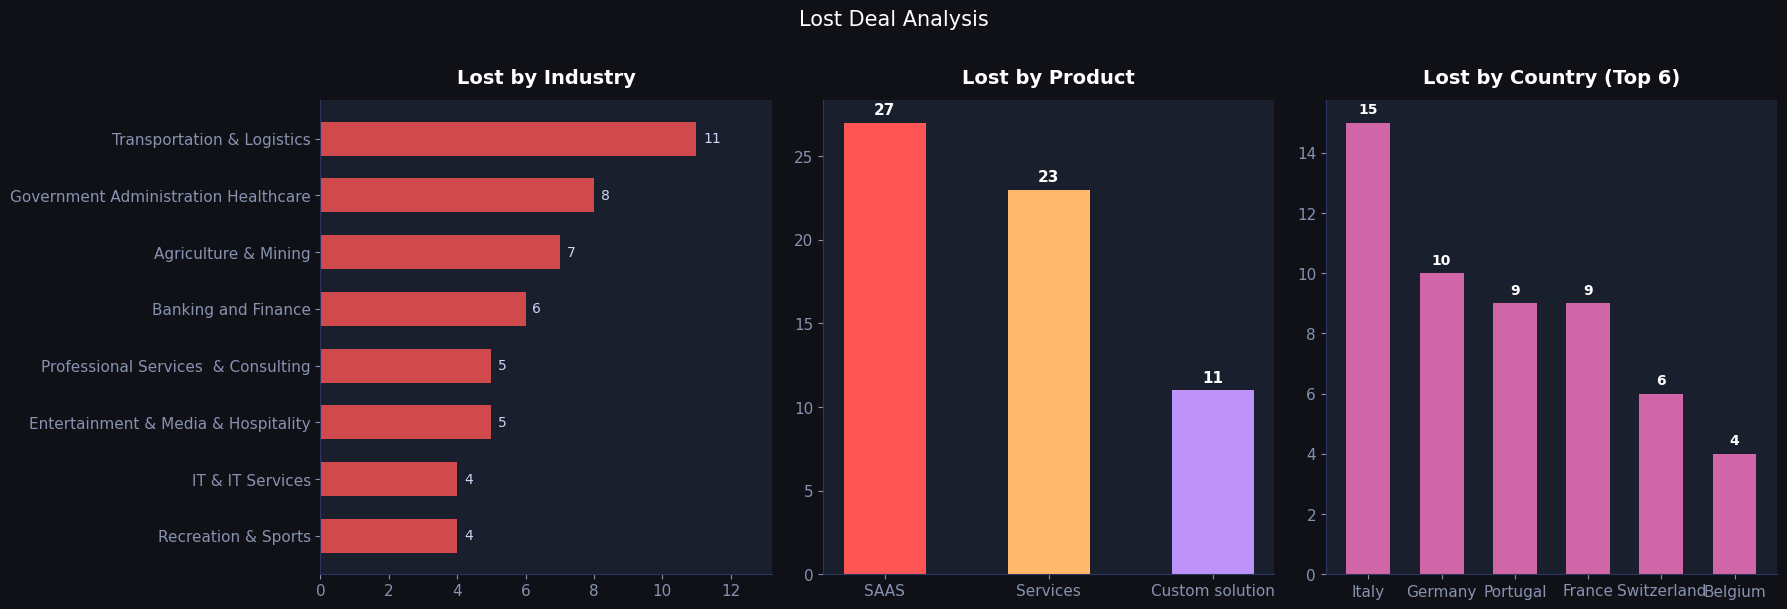

In [18]:
lost_df = df[df['is_lost']]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Lost Deal Analysis', fontsize=15, color='#fff', y=1.01)

# Industry
li = lost_df['Industry'].value_counts().head(8)
axes[0].barh(li.index[::-1], li.values[::-1], color='#ff5555', alpha=0.8, edgecolor='none', height=0.6)
for i, (idx, val) in enumerate(zip(li.index[::-1], li.values[::-1])):
    axes[0].text(val + 0.2, i, str(val), va='center', fontsize=10, color='#cdd6f4')
axes[0].set_title('Lost by Industry', color='#fff')
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)
axes[0].set_xlim(0, li.max() * 1.2)

# Product
lp = lost_df['Product'].value_counts()
axes[1].bar(lp.index, lp.values, color=['#ff5555','#ffb86c','#bd93f9'][:len(lp)],
            edgecolor='none', width=0.5)
for i, (idx, val) in enumerate(lp.items()):
    axes[1].text(i, val + 0.3, str(val), ha='center', va='bottom', fontsize=11, fontweight='bold', color='#fff')
axes[1].set_title('Lost by Product', color='#fff')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

# Country
lc = lost_df['Country'].value_counts().head(6)
axes[2].bar(lc.index, lc.values, color='#ff79c6', alpha=0.8, edgecolor='none', width=0.6)
for i, (idx, val) in enumerate(lc.items()):
    axes[2].text(i, val + 0.2, str(val), ha='center', va='bottom', fontsize=10, fontweight='bold', color='#fff')
axes[2].set_title('Lost by Country (Top 6)', color='#fff')
axes[2].spines['top'].set_visible(False); axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('09_lost_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

###  Nhận xét kết quả


- **Italy: 15 lost** nhưng Italy có 620 leads → lost rate thực ra chỉ ~2.4%
- **Agriculture & Mining: 7 lost** nhưng n nhỏ → lost rate thực sự cao hơn tỷ lệ

**Về Product:** SAAS nhiều lost nhất (27) nhưng cũng là product phổ biến nhất → cần normalize. Custom solution ít lost nhất (11) nhưng cũng ít được bán nhất. Cần tính lost_rate = lost/(won+lost) theo product để so sánh công bằng.


### 6.2 Win vs Lost Heatmap — Cross-analysis

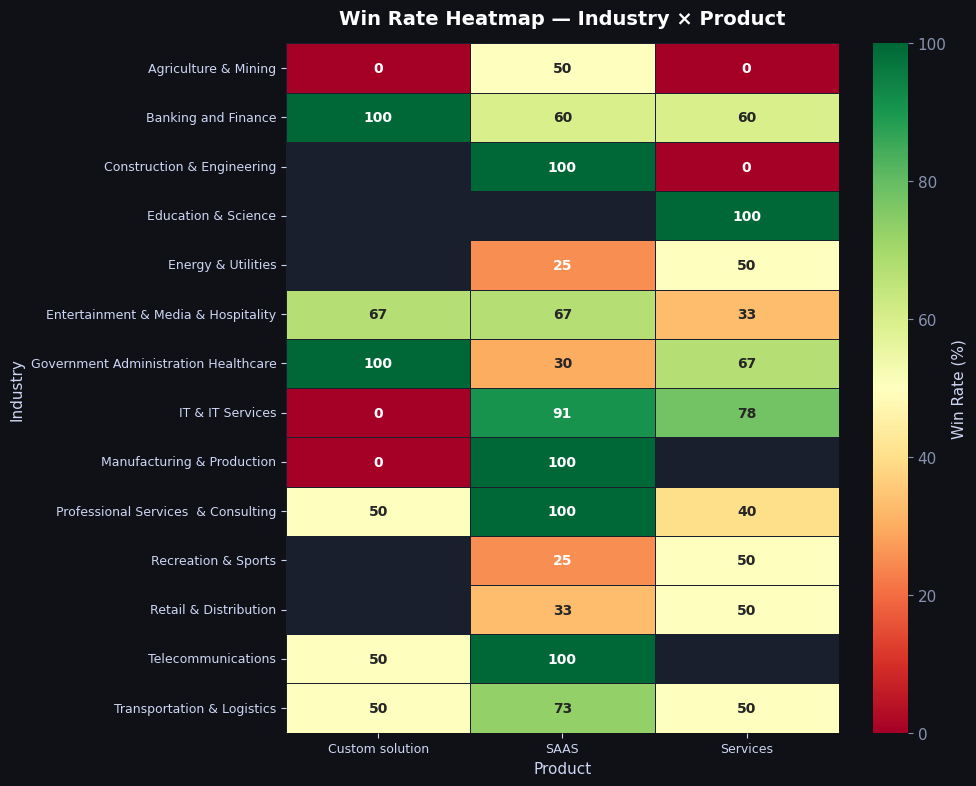


 Ô màu đỏ = cần tập trung cải thiện. Ô xanh = đang làm tốt.


In [19]:
# Win rate heatmap: Industry × Product
pivot = closed.groupby(['Industry','Product']).apply(
    lambda x: round(x['is_won'].sum() / len(x) * 100, 0)
).unstack(fill_value=np.nan)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0f1117')
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn',
            linewidths=0.5, linecolor='#1a1f2e',
            ax=ax, vmin=0, vmax=100,
            annot_kws={'size': 10, 'weight': 'bold'},
            cbar_kws={'label': 'Win Rate (%)'})
ax.set_title('Win Rate Heatmap — Industry × Product', color='#fff', pad=14)
ax.set_xlabel('Product', color='#cdd6f4')
ax.set_ylabel('Industry', color='#cdd6f4')
ax.tick_params(colors='#cdd6f4', labelsize=9)
plt.tight_layout()
plt.savefig('10_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print("\n Ô màu đỏ = cần tập trung cải thiện. Ô xanh = đang làm tốt.")

### Nhận xét kết quả

- IT Services + SAAS → đây thường là **ô xanh nhất** — thị trường "natural fit" rõ ràng
- Agriculture + Custom Solution → thường là **ô đỏ** hoặc NaN (không đủ data)
- Các ô NaN (màu trắng/xám): chưa từng thử bán tổ hợp này → cơ hội hoặc chủ ý tránh

**Insight chiến lược:** Tập trung Sales vào các ô xanh (high win-rate combinations) và xem xét dừng invest vào ô đỏ với n đủ lớn.


### 6.3 Org Size Analysis

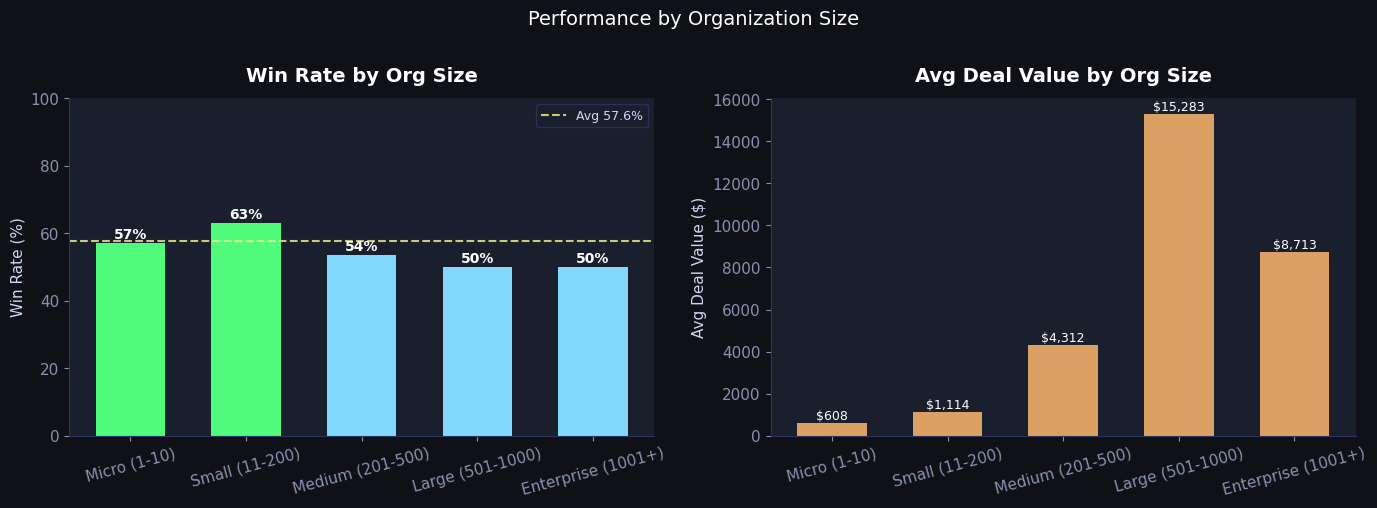

                    deals  won  avg_val  win_rate
org_size_cat                                     
Micro (1-10)           28   16    608.2      57.1
Small (11-200)         54   34   1113.9      63.0
Medium (201-500)       56   30   4312.0      53.6
Large (501-1000)        2    1  15283.0      50.0
Enterprise (1001+)      4    2   8713.0      50.0


In [20]:
size_stats = closed.groupby('org_size_cat').agg(
    deals    = ('is_won','count'),
    won      = ('is_won','sum'),
    avg_val  = ('Deal Value, $', 'mean')
).assign(win_rate = lambda x: x['won']/x['deals']*100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Performance by Organization Size', fontsize=14, color='#fff', y=1.01)

# Win rate by size
c1 = ['#50fa7b' if v >= 55 else '#80d8ff' if v >= 45 else '#ff5555'
      for v in size_stats['win_rate']]
axes[0].bar(size_stats.index, size_stats['win_rate'], color=c1, edgecolor='none', width=0.6)
axes[0].axhline(y=hist_wr*100, color='#f1fa8c', linestyle='--', alpha=0.8, label=f'Avg {hist_wr*100:.1f}%')
for i, (idx, row) in enumerate(size_stats.iterrows()):
    axes[0].text(i, row['win_rate'] + 0.5, f"{row['win_rate']:.0f}%",
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#fff')
axes[0].set_title('Win Rate by Org Size', color='#fff')
axes[0].set_ylabel('Win Rate (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(facecolor='#1a1f2e', edgecolor='#2d3561', fontsize=9)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Avg deal value by size
axes[1].bar(size_stats.index, size_stats['avg_val'], color='#ffb86c', alpha=0.85, edgecolor='none', width=0.6)
for i, (idx, row) in enumerate(size_stats.iterrows()):
    axes[1].text(i, row['avg_val'] + 30, f"${row['avg_val']:,.0f}",
                 ha='center', va='bottom', fontsize=9, color='#fff')
axes[1].set_title('Avg Deal Value by Org Size', color='#fff')
axes[1].set_ylabel('Avg Deal Value ($)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('11_org_size.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print(size_stats.round(1).to_string())

###  Nhận xét kết quả

Đây là phân tích **segmentation** quan trọng cho chiến lược Go-to-Market. Hai điều thường xảy ra trong B2B SaaS:

1. **Enterprise deals** (1001+) có **avg deal value cao nhất** nhưng win rate thấp hơn — cycle dài, nhiều stakeholders, competitive procurement
2. **SMB deals** (Micro/Small) win rate cao hơn nhưng deal value nhỏ — phải close nhiều hơn để đạt cùng doanh thu

Nếu data cho thấy Mid-market (Medium: 201-500) có **win rate cao + avg value cao** → đây là **"Goldilocks segment"** mà công ty nên tập trung. Đây là framework ICP (Ideal Customer Profile) dựa trên data thực tế.
